In [1]:
import pandas as pd
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse, mae
import numpy as np
import math
from sklearn.metrics.pairwise import cosine_similarity
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


In [2]:


# Đọc file ratings.dat
ratings_df = pd.read_csv('ratings.dat', sep='::', engine='python', 
                      names=['UserId', 'MovieId', 'Rating', 'Timestamp'])

# Đọc file tags.dat
tags_df = pd.read_csv('tags.dat', sep='::', engine='python', 
                   names=['UserId', 'MovieId', 'Tag', 'Timestamp'])

# Đọc file movies.dat
movies_df = pd.read_csv('movies.dat', sep='::', engine='python', 
                     names=['MovieId', 'Title', 'Genres'])

In [3]:
ratings_df.describe()

,UserId,MovieId,Rating,Timestamp
count,1.000005e+07,1.000005e+07,1.000005e+07,1.000005e+07
mean,3.586986e+04,4.120291e+03,3.512422e+00,1.032606e+09
std,2.058534e+04,8.938402e+03,1.060418e+00,1.159640e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,1.812300e+04,6.480000e+02,3.000000e+00,9.467659e+08
50%,3.574050e+04,1.834000e+03,4.000000e+00,1.035476e+09
75%,5.360800e+04,3.624000e+03,4.000000e+00,1.126749e+09
max,7.156700e+04,6.513300e+04,5.000000e+00,1.231132e+09


In [4]:
ratings_df.duplicated(subset=['UserId', 'MovieId']).sum()

0

In [5]:
# Lọc user >= 5 ratings
user_counts = ratings_df.groupby('UserId').size()
ratings_df = ratings_df[ratings_df['UserId'].isin(user_counts[user_counts >= 5].index)]

# Lọc movie >= 5 ratings
movie_counts = ratings_df.groupby('MovieId').size()
ratings_df = ratings_df[ratings_df['MovieId'].isin(movie_counts[movie_counts >= 5].index)]

In [6]:
n_users = ratings_df['UserId'].nunique()
n_movies = ratings_df['MovieId'].nunique()
n_ratings = len(ratings_df)

sparsity = 1 - (n_ratings / (n_users * n_movies))
print("Sparsity:", sparsity)

Sparsity: 0.9859661030476576


In [7]:
ratings_df.groupby('UserId').size().describe()


count    69878.000000
mean       143.089613
std        216.543129
min         18.000000
25%         35.000000
50%         69.000000
75%        156.000000
max       7240.000000
dtype: float64

In [8]:
ratings_df.groupby('MovieId').size().describe()

count    10196.000000
mean       980.660651
std       2536.847198
min          5.000000
25%         41.000000
50%        152.000000
75%        684.250000
max      34864.000000
dtype: float64

In [9]:
tags_df.isnull().sum()

UserId        0
MovieId       0
Tag          16
Timestamp     0
dtype: int64

In [10]:
# Loại bỏ các hàng có dữ liệu thiếu
ratings_df.dropna(inplace=True)
tags_df.dropna(inplace=True)
movies_df.dropna(inplace=True)

In [11]:
ratings_df['Timestamp'] = pd.to_datetime(ratings_df['Timestamp'], unit='s')
tags_df['Timestamp'] = pd.to_datetime(tags_df['Timestamp'], unit='s')

In [12]:
ratings_df.head()

,UserId,MovieId,Rating,Timestamp
0,1,122,5.0,1996-08-02 11:24:06
1,1,185,5.0,1996-08-02 10:58:45
2,1,231,5.0,1996-08-02 10:56:32
3,1,292,5.0,1996-08-02 10:57:01
4,1,316,5.0,1996-08-02 10:56:32


In [13]:


# Cấu hình style cho biểu đồ
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print(f"Ratings: {len(ratings_df)} records")
print(f"Movies: {len(movies_df)} records")
print("\n=== THỐNG KÊ CƠ BẢN ===")
print(f"Số người dùng: {ratings_df['UserId'].nunique()}")
print(f"Số phim: {ratings_df['MovieId'].nunique()}")
print(f"Tổng số ratings: {len(ratings_df)}")
print(f"Điểm trung bình: {ratings_df['Rating'].mean():.2f}")
print(f"Độ lệch chuẩn: {ratings_df['Rating'].std():.2f}")
print(f"Điểm min: {ratings_df['Rating'].min()}")
print(f"Điểm max: {ratings_df['Rating'].max()}")

Ratings: 9998816 records
Movies: 10681 records

=== THỐNG KÊ CƠ BẢN ===
Số người dùng: 69878
Số phim: 10196
Tổng số ratings: 9998816
Điểm trung bình: 3.51
Độ lệch chuẩn: 1.06
Điểm min: 0.5
Điểm max: 5.0


C:\Users\PC\AppData\Local\Temp\ipykernel_28204\260219104.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ratings_df, x='Rating', palette='viridis', order=sorted(ratings_df['Rating'].unique()))


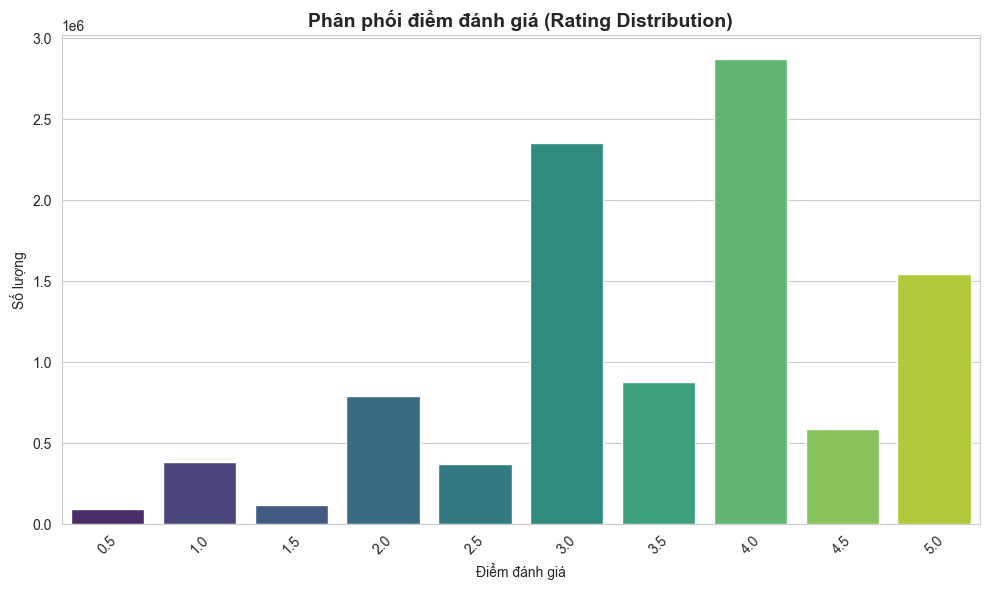

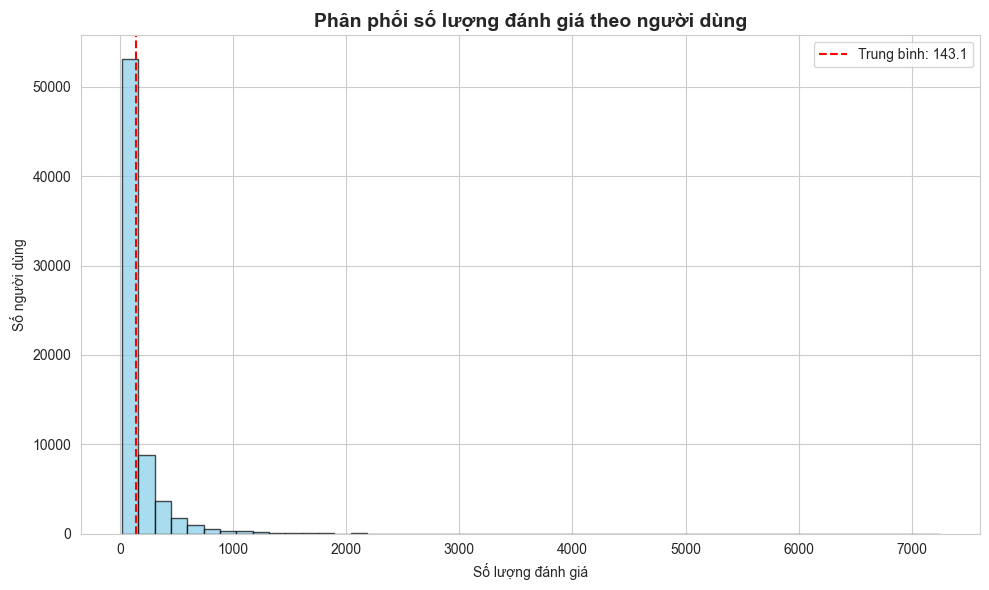

In [14]:
# ---- Biểu đồ 1: Phân phối điểm đánh giá ----
plt.figure(figsize=(10, 6))
sns.countplot(data=ratings_df, x='Rating', palette='viridis', order=sorted(ratings_df['Rating'].unique()))
plt.title('Phân phối điểm đánh giá (Rating Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Điểm đánh giá')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- Biểu đồ 2: Thống kê số ratings theo người dùng ----
user_ratings_count = ratings_df.groupby('UserId').size().reset_index(name='Count')

plt.figure(figsize=(10, 6))
plt.hist(user_ratings_count['Count'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Phân phối số lượng đánh giá theo người dùng', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng đánh giá')
plt.ylabel('Số người dùng')
plt.axvline(user_ratings_count['Count'].mean(), color='red', linestyle='--', 
            label=f'Trung bình: {user_ratings_count["Count"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

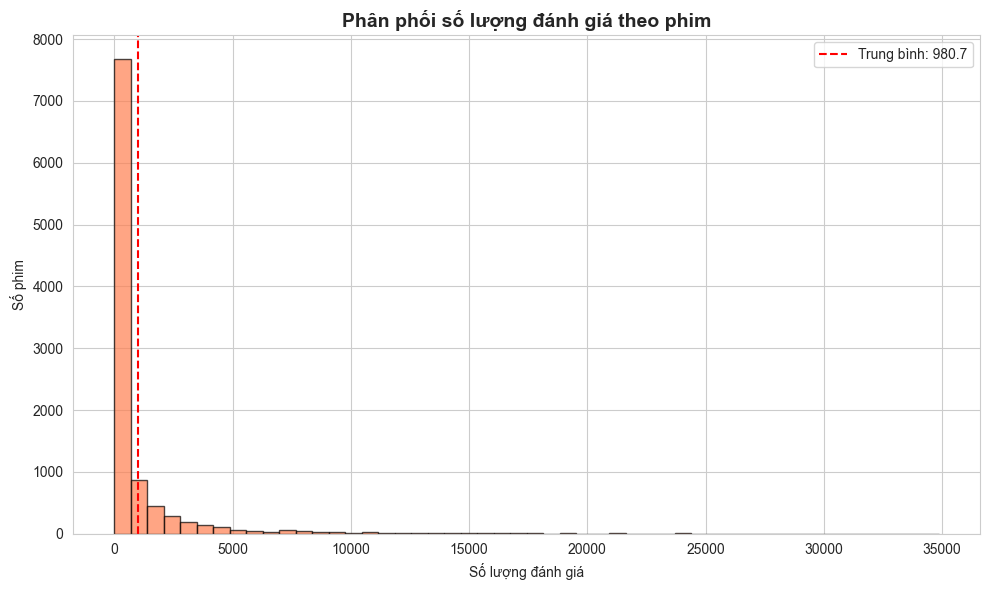

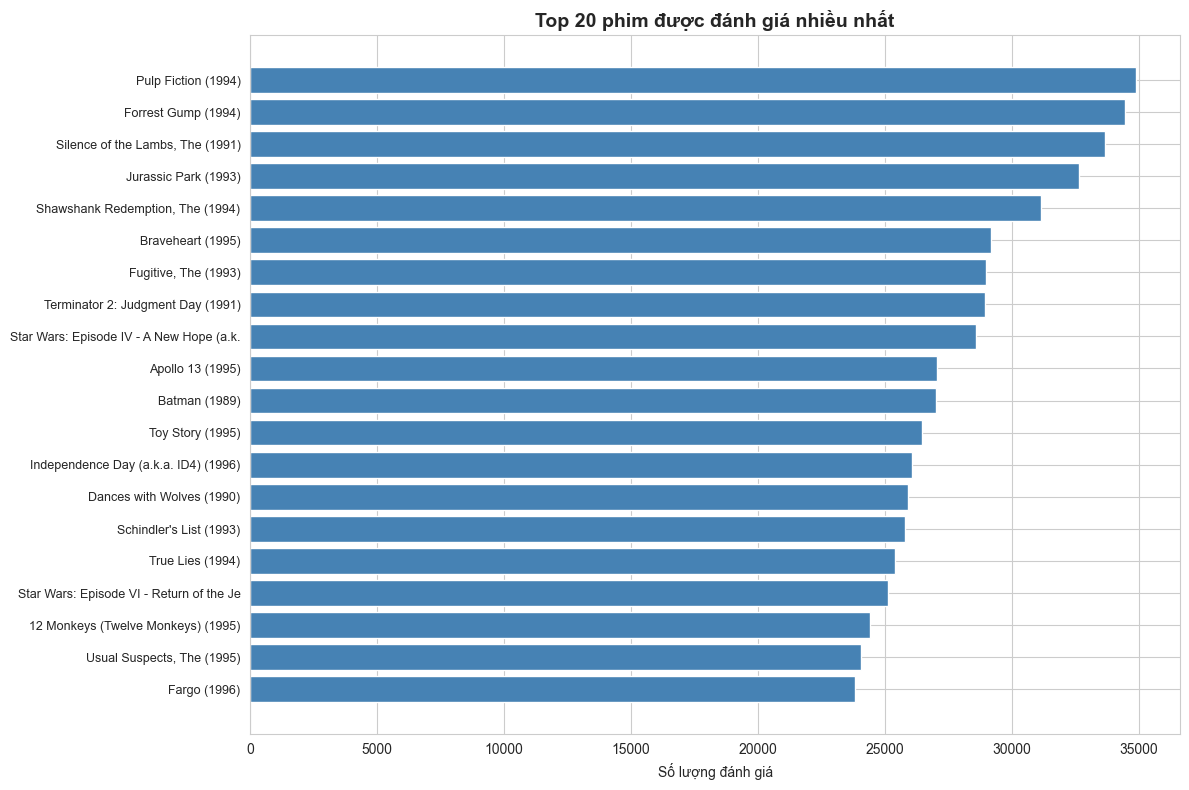

In [15]:
# ---- Biểu đồ 3: Thống kê số ratings theo phim ----
movie_ratings_count = ratings_df.groupby('MovieId').size().reset_index(name='Count')

plt.figure(figsize=(10, 6))
plt.hist(movie_ratings_count['Count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.title('Phân phối số lượng đánh giá theo phim', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng đánh giá')
plt.ylabel('Số phim')
plt.axvline(movie_ratings_count['Count'].mean(), color='red', linestyle='--',
            label=f'Trung bình: {movie_ratings_count["Count"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Biểu đồ 4: Top 20 phim được đánh giá nhiều nhất ----
top_movies = movie_ratings_count.nlargest(20, 'Count')
top_movies_titles = pd.merge(top_movies, movies_df[['MovieId', 'Title']], on='MovieId')

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_movies_titles)), top_movies_titles['Count'], color='steelblue')
plt.yticks(range(len(top_movies_titles)), top_movies_titles['Title'].str[:40], fontsize=9)
plt.gca().invert_yaxis()
plt.title('Top 20 phim được đánh giá nhiều nhất', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng đánh giá')
plt.tight_layout()
plt.show()


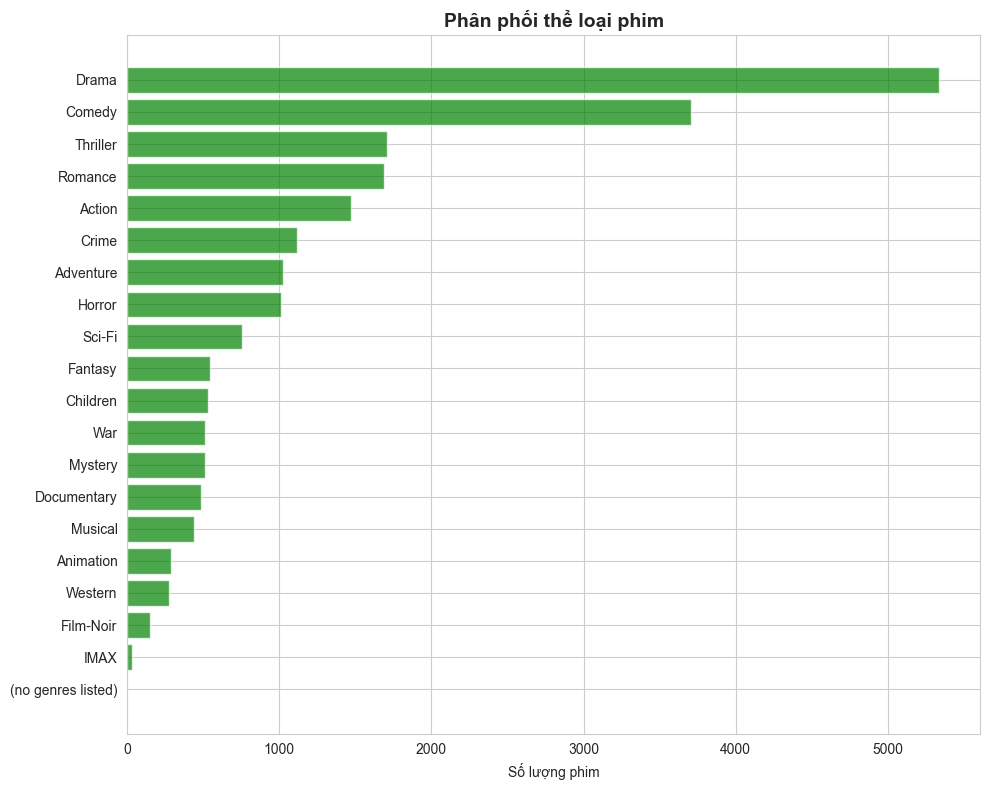

In [16]:
# ---- Biểu đồ 5: Phân phối thể loại phim ----
# Tách các genre
all_genres = []
for genres in movies_df['Genres'].dropna():
    all_genres.extend(genres.split('|'))

genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(list(genre_counts.items()), columns=['Genre', 'Count'])
genre_df = genre_df.sort_values('Count', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(genre_df['Genre'], genre_df['Count'], color='green', alpha=0.7)
plt.title('Phân phối thể loại phim', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng phim')
plt.tight_layout()
plt.show()

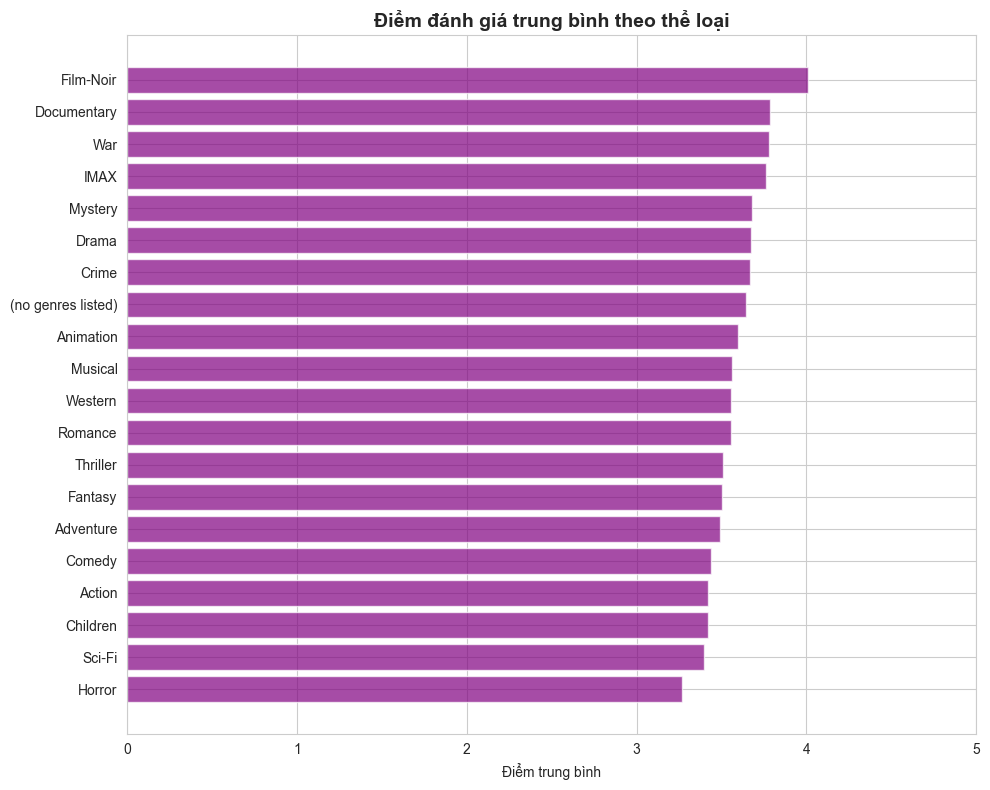

In [17]:

# Tạo dataframe với từng genre riêng biệt
movies_genres = movies_df.explode('Genres')
movies_genres['Genres'] = movies_genres['Genres'].str.split('|')
movies_genres = movies_genres.explode('Genres')

# Merge với ratings
ratings_with_genres = pd.merge(ratings_df, movies_df[['MovieId', 'Genres']], on='MovieId')
ratings_with_genres['Genres'] = ratings_with_genres['Genres'].str.split('|')
ratings_with_genres = ratings_with_genres.explode('Genres')

# Tính điểm trung bình theo genre
avg_rating_by_genre = ratings_with_genres.groupby('Genres')['Rating'].mean().sort_values()

plt.figure(figsize=(10, 8))
plt.barh(avg_rating_by_genre.index, avg_rating_by_genre.values, color='purple', alpha=0.7)
plt.title('Điểm đánh giá trung bình theo thể loại', fontsize=14, fontweight='bold')
plt.xlabel('Điểm trung bình')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

# Load
df = ratings_df[["UserId", "MovieId", "Rating"]].copy()

# 80% train, 20% temp
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

# 10% val, 10% test
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(len(train_df), len(val_df), len(test_df))

7999052 999882 999882


In [19]:
from surprise import Dataset, Reader, SVD

reader = Reader(rating_scale=(0.5, 5.0))

train_data = Dataset.load_from_df(
    train_df[["UserId", "MovieId", "Rating"]],
    reader
)

trainset = train_data.build_full_trainset()

model_SVD = SVD(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

model_SVD.fit(trainset)

In [20]:
from surprise import NMF

# NMF trong surprise dùng tên tham số hơi khác SVD một chút
nmf_model = NMF(
    n_factors=50,      # Giữ nguyên số latent factors
    n_epochs=20,              # Thay reg_all → reg
    random_state=42    # Giữ seed để tái lập kết quả
)

print("🔄 Đang train NMF...")
nmf_model.fit(trainset)
print("✅ NMF huấn luyện hoàn tất!")

🔄 Đang train NMF...
✅ NMF huấn luyện hoàn tất!


In [ ]:
from surprise import SVDpp

model_SVDpp = SVDpp(
    n_factors=40,
    n_epochs=12,
    lr_all=0.007,
    reg_all=0.02,
    random_state=42
)
model_SVDpp.fit(trainset)

In [14]:
from sklearn.metrics import mean_squared_error

def evaluate_rmse(df_eval,model):
    y_true = []
    y_pred = []

    for _, row in df_eval.iterrows():
        pred = model.predict(row["UserId"], row["MovieId"]).est
        y_true.append(row["Rating"])
        y_pred.append(pred)

    return np.sqrt(mean_squared_error(y_true, y_pred))





In [15]:
from sklearn.metrics import ndcg_score

def evaluate_ndcg(df_eval,model, k=10):
    user_groups = df_eval.groupby("UserId")
    ndcg_list = []

    for user, group in user_groups:
        true_scores = group["Rating"].values.reshape(1, -1)
        pred_scores = np.array([
            model.predict(user, item).est for item in group["MovieId"]
        ]).reshape(1, -1)

        if len(true_scores[0]) > 1:
            ndcg = ndcg_score(true_scores, pred_scores, k=k)
            ndcg_list.append(ndcg)

    return np.mean(ndcg_list)




In [16]:
def evaluate_ranking_metrics(df_eval,model, k=10, threshold=4.0):
    user_groups = df_eval.groupby("UserId")
    
    precisions = []
    recalls = []
    hit_rates = []
    
    for user, group in user_groups:
        item_preds = []
        
        # Dự đoán điểm cho tất cả các item của user trong tập eval
        for _, row in group.iterrows():
            est = model.predict(user, row["MovieId"]).est
            item_preds.append((est, row["Rating"]))
            
        # Sắp xếp giảm dần theo điểm dự đoán (est)
        item_preds.sort(key=lambda x: x[0], reverse=True)
        
        # Lấy Top K item được model đánh giá cao nhất
        top_k = item_preds[:k]
        
        # Đếm số lượng item thực sự relevant (thực tế user đánh giá >= threshold)
        n_rel = sum((true_r >= threshold) for (_, true_r) in item_preds)
        
        # Đếm số lượng item relevant xuất hiện trong Top K (Hits)
        n_rel_and_rec_k = sum((true_r >= threshold) for (_, true_r) in top_k)
        
        # Chỉ tính toán cho các user thực sự có item relevant trong tập eval này
        if n_rel > 0:
            # Precision@K: Tỉ lệ dự đoán đúng trong Top K
            precisions.append(n_rel_and_rec_k / len(top_k))
            
            # Recall@K: Tỉ lệ tìm được so với tổng số item relevant của user đó
            recalls.append(n_rel_and_rec_k / n_rel)
            
            # HitRate@K: Bằng 1 nếu có ít nhất 1 item relevant lọt vào Top K, ngược lại là 0
            hit_rates.append(1 if n_rel_and_rec_k > 0 else 0)
            
    return np.mean(precisions), np.mean(recalls), np.mean(hit_rates)

# Chạy thử trên tập Val và Test




In [24]:

test_precision, test_recall, test_hit_rate = evaluate_ranking_metrics(test_df, k=10, threshold=4.0, model=nmf_model)
print(f"Test Precision@10: {test_precision:.4f} | Test Recall@10: {test_recall:.4f} | Test HitRate@10: {test_hit_rate:.4f}")
print("Test NDCG@10:", evaluate_ndcg(test_df, model=nmf_model))
print("RMSE Test:", evaluate_rmse(test_df, model=nmf_model))


Test Precision@10: 0.6123 | Test Recall@10: 0.8185 | Test HitRate@10: 0.9987
Test NDCG@10: 0.9075260093594054
RMSE Test: 1.6325946491823782


In [17]:
print(f"Avg items per user in val_df: {test_df.groupby('UserId').size().mean():.2f}")

Avg items per user in val_df: 14.60


In [18]:
import random

def evaluate_with_sampling(df_eval, model, train_df, all_movie_ids, k=10, 
                           n_neg_samples=100, threshold=4.0):
    """
    Đánh giá với Positive + Negative Sampling
    
    Parameters:
    -----------
    df_eval: tập val/test cần đánh giá
    model: mô hình đã train
    train_df: tập train (để biết user đã xem phim nào)
    all_movie_ids: danh sách tất cả movie IDs trong hệ thống
    k: top-k để đánh giá
    n_neg_samples: số lượng negative samples cho mỗi user
    threshold: ngưỡng rating để coi là relevant
    """
    
    user_groups = df_eval.groupby("UserId")
    ndcg_list = []
    precisions = []
    recalls = []
    hit_rates = []
    
    for user, group in user_groups:
        # 1. Positive items: các phim trong tập eval (user đã rating)
        positive_items = set(group["MovieId"].values)
        
        # 2. Movies user đã rating trong train (loại khỏi candidate pool)
        rated_in_train = set(train_df[train_df["UserId"] == user]["MovieId"])
        
        # 3. Candidate pool = positive items + negative samples
        # Negative: phim user CHƯA từng xem (không có trong train và không có trong eval)
        unseen_movies = [m for m in all_movie_ids 
                        if m not in rated_in_train and m not in positive_items]
        
        # Sample ngẫu nhiên negative items
        n_neg = min(n_neg_samples, len(unseen_movies))
        negative_items = random.sample(unseen_movies, n_neg)
        
        # Candidate pool cuối cùng
        candidate_items = list(positive_items) + negative_items
        
        # 4. Predict scores cho tất cả candidate items
        pred_scores = []
        true_scores = []
        
        for movie_id in candidate_items:
            pred = model.predict(user, movie_id).est
            pred_scores.append(pred)
            
            # True score: nếu movie có trong eval set → lấy rating thật
            # Nếu không → 0 (negative)
            if movie_id in positive_items:
                rating = group[group["MovieId"] == movie_id]["Rating"].values[0]
                true_scores.append(rating)
            else:
                true_scores.append(0)  # Negative sample
        
        # 5. Tính NDCG@k
        if len(set(true_scores)) > 1:  # Có cả positive và negative
            ndcg = ndcg_score([true_scores], [pred_scores], k=k)
            ndcg_list.append(ndcg)
        
        # 6. Tính Precision, Recall, HitRate@k
        # Sắp xếp theo điểm dự đoán
        item_preds = list(zip(candidate_items, pred_scores, true_scores))
        item_preds.sort(key=lambda x: x[1], reverse=True)  # Sort by pred score
        
        top_k = item_preds[:k]
        
        # Đếm relevant items (rating >= threshold)
        n_rel = sum(1 for (_, _, true_r) in item_preds if true_r >= threshold)
        n_rel_and_rec_k = sum(1 for (_, _, true_r) in top_k if true_r >= threshold)
        
        if n_rel > 0:
            precisions.append(n_rel_and_rec_k / len(top_k))
            recalls.append(n_rel_and_rec_k / n_rel)
            hit_rates.append(1 if n_rel_and_rec_k > 0 else 0)
    
    # 7. Return kết quả
    results = {
        'NDCG@10': np.mean(ndcg_list) if ndcg_list else 0,
        'Precision@10': np.mean(precisions) if precisions else 0,
        'Recall@10': np.mean(recalls) if recalls else 0,
        'HitRate@10': np.mean(hit_rates) if hit_rates else 0
    }
    
    return results

In [19]:
all_movies = ratings_df['MovieId'].unique()
print(f"Tổng số phim trong hệ thống: {len(all_movies)}")

Tổng số phim trong hệ thống: 10196


In [21]:
from sklearn.model_selection import ParameterGrid
from surprise import SVD
import pandas as pd
import numpy as np
from tqdm import tqdm
import random

reader = Reader(rating_scale=(0.5, 5.0))
def build_trainset(df):
    data = Dataset.load_from_df(
        df[["UserId", "MovieId", "Rating"]],
        reader
    )
    return data.build_full_trainset()

# 1. Giảm grid: chỉ tune 2 tham số quan trọng nhất
param_grid = {
    "n_factors": [50, 80, 100],
    "n_epochs": [15, 20, 25]
}
# Fix các tham số ít nhạy
FIXED_PARAMS = {"lr_all": 0.005, "reg_all": 0.02, "random_state": 42}

# 2. Subsample val_df để eval nhanh (chỉ 1000 user)
val_subset = val_df.groupby("UserId").head(1)  # lấy 1 user làm đại diện
val_subset = val_df[val_df["UserId"].isin(val_subset["UserId"].unique()[:1000])]

# 3. Giảm negative samples trong quá trình tune
TUNE_NEG_SAMPLES = 5

results = []
trainset = build_trainset(train_df)

for params in tqdm(ParameterGrid(param_grid), desc="🔍 Grid Search"):
    full_params = {**params, **FIXED_PARAMS}
    model = SVD(**full_params)
    model.fit(trainset)
    
    # Eval nhanh trên subset
    metrics = evaluate_with_sampling(
        val_subset, model, train_df, all_movies,
        k=10, n_neg_samples=TUNE_NEG_SAMPLES, threshold=4.0
    )
    
    results.append({
        **full_params,
        "val_ndcg@10": metrics["NDCG@10"],
        "val_precision@10": metrics["Precision@10"],
        "val_recall@10": metrics["Recall@10"]
    })

# Sắp xếp & lưu
grid_df = pd.DataFrame(results).sort_values("val_ndcg@10", ascending=False).reset_index(drop=True)
grid_df.to_csv("grid_search_results.csv", index=False)
print("\n✅ Top 5 kết quả:")
print(grid_df.head())

🔍 Grid Search: 100%|██████████| 9/9 [29:41<00:00, 197.96s/it]


✅ Top 5 kết quả:
   n_epochs  n_factors  lr_all  reg_all  random_state  val_ndcg@10  \
0        25        100   0.005     0.02            42     0.857777   
1        25         50   0.005     0.02            42     0.856625   
2        25         80   0.005     0.02            42     0.855719   
3        20         80   0.005     0.02            42     0.854060   
4        20        100   0.005     0.02            42     0.852640   

   val_precision@10  val_recall@10  
0          0.655622       0.554346  
1          0.655017       0.554560  
2          0.654916       0.553827  
3          0.652900       0.553431  
4          0.653807       0.551024  


In [ ]:
from sklearn.model_selection import ParameterGrid
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split
import pandas as pd
import numpy as np
import random

reader = Reader(rating_scale=(0.5, 5.0))

def build_trainset(df):
    data = Dataset.load_from_df(
        df[["UserId", "MovieId", "Rating"]],
        reader
    )
    return data.build_full_trainset()

def evaluate_rmse(df, model):
    preds = [
        model.predict(row.UserId, row.MovieId, row.Rating)
        for row in df.itertuples()
    ]
    return accuracy.rmse(preds, verbose=False)

param_grid = {
    "n_factors": [50, 80],
    "n_epochs": [20, 30],
    "lr_all": [0.002, 0.005, 0.007],
    "reg_all": [0.02, 0.05, 0.1]
}

trainset = build_trainset(train_df)

results = []

for params in ParameterGrid(param_grid):
    model = SVD(
        n_factors=params["n_factors"],
        n_epochs=params["n_epochs"],
        lr_all=params["lr_all"],
        reg_all=params["reg_all"],
        random_state=42
    )

    model.fit(trainset)

    random.seed(42)
    np.random.seed(42)

    val_metrics = evaluate_with_sampling(
        val_df,
        model,
        train_df,
        all_movies,
        k=10,
        n_neg_samples=20,
        threshold=4.0
    )

    results.append({
        **params,
        "val_rmse": evaluate_rmse(val_df, model),
        "val_precision@10": val_metrics["Precision@10"],
        "val_recall@10": val_metrics["Recall@10"],
        "val_hit_rate@10": val_metrics["HitRate@10"],
        "val_ndcg@10": val_metrics["NDCG@10"],
    })

grid_results_df = pd.DataFrame(results)

grid_results_df = grid_results_df.sort_values(
    by="val_ndcg@10",
    ascending=False
).reset_index(drop=True)

grid_results_df.head(10)

In [ ]:
from surprise import NMF
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
import random

param_grid = {
    "n_factors": [15, 30, 50],
    "n_epochs": [50, 80, 100],
    "reg_pu": [0.02, 0.06, 0.1],
    "reg_qi": [0.02, 0.06, 0.1],
    "biased": [False, True]
}

trainset = build_trainset(train_df)

results = []

for params in ParameterGrid(param_grid):
    model = NMF(
        n_factors=params["n_factors"],
        n_epochs=params["n_epochs"],
        reg_pu=params["reg_pu"],
        reg_qi=params["reg_qi"],
        biased=params["biased"],
        random_state=42
    )

    model.fit(trainset)

    random.seed(42)
    np.random.seed(42)

    val_metrics = evaluate_with_sampling(
        val_df,
        model,
        train_df,
        all_movies,
        k=10,
        n_neg_samples=20,
        threshold=4.0
    )

    results.append({
        **params,
        "val_rmse": evaluate_rmse(val_df, model),
        "val_precision@10": val_metrics["Precision@10"],
        "val_recall@10": val_metrics["Recall@10"],
        "val_hit_rate@10": val_metrics["HitRate@10"],
        "val_ndcg@10": val_metrics["NDCG@10"],
    })

grid_results_df = pd.DataFrame(results)

grid_results_df = grid_results_df.sort_values(
    by="val_ndcg@10",
    ascending=False
).reset_index(drop=True)

grid_results_df.head(10)

In [ ]:
# Chuẩn bị dữ liệu

# Đặt random seed để tái lập kết quả
random.seed(42)
np.random.seed(42)
val_results = evaluate_with_sampling(
    val_df, model_SVD, train_df, all_movies,
    k=10, n_neg_samples=20, threshold=4.0
)

print("\nKết quả trên Val Set (100 negative samples):")
print(f"  NDCG@10:      {val_results['NDCG@10']:.6f}")
print(f"  Precision@10: {val_results['Precision@10']:.4f}")
print(f"  Recall@10:    {val_results['Recall@10']:.4f}")
print(f"  HitRate@10:   {val_results['HitRate@10']:.4f}")

# Với tập Test
test_results = evaluate_with_sampling(
    test_df, model_SVD, train_df, all_movies,
    k=10, n_neg_samples=20, threshold=4.0
)

print("\n📊 Kết quả trên Test Set (100 negative samples):")
print(f"  NDCG@10:      {test_results['NDCG@10']:.6f}")
print(f"  Precision@10: {test_results['Precision@10']:.4f}")
print(f"  Recall@10:    {test_results['Recall@10']:.4f}")
print(f"  HitRate@10:   {test_results['HitRate@10']:.4f}")

Tổng số phim trong hệ thống: 10196

Kết quả trên Val Set (100 negative samples):
  NDCG@10:      0.592071
  Precision@10: 0.3596
  Recall@10:    0.6368
  HitRate@10:   0.9474

📊 Kết quả trên Test Set (100 negative samples):
  NDCG@10:      0.592505
  Precision@10: 0.3605
  Recall@10:    0.6365
  HitRate@10:   0.9468


In [28]:
# Với tập Test
test_results = evaluate_with_sampling(
    test_df, model_SVDpp, train_df, all_movies,
    k=10, n_neg_samples=20, threshold=4.0
)

print("\n📊 Kết quả model SVD++ trên Test Set (20 negative samples):")
print(f"  NDCG@10:      {test_results['NDCG@10']:.6f}")
print(f"  Precision@10: {test_results['Precision@10']:.4f}")
print(f"  Recall@10:    {test_results['Recall@10']:.4f}")
print(f"  HitRate@10:   {test_results['HitRate@10']:.4f}")

# Với tập Test
test_results = evaluate_with_sampling(
    test_df, nmf_model, train_df, all_movies,
    k=10, n_neg_samples=20, threshold=4.0
)

print("\n📊 Kết quả model NMF trên Test Set (20 negative samples):")
print(f"  NDCG@10:      {test_results['NDCG@10']:.6f}")
print(f"  Precision@10: {test_results['Precision@10']:.4f}")
print(f"  Recall@10:    {test_results['Recall@10']:.4f}")
print(f"  HitRate@10:   {test_results['HitRate@10']:.4f}")

NameError: name 'model_SVDpp' is not defined

#   COLD-START

In [20]:
movies_cb = movies_df[["MovieId", "Title", "Genres"]].copy()
movies_cb["Genres"] = movies_cb["Genres"].fillna("")
movies_cb.head()

,MovieId,Title,Genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [22]:
genre_features = movies_cb["Genres"].str.get_dummies(sep="|")
genre_features.head(10)

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
7,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [23]:
movie_content_df = pd.concat(
    [movies_cb[["MovieId", "Title", "Genres"]], genre_features],
    axis=1
)

movie_content_df.head()

,MovieId,Title,Genres,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


PHẦN NÀY ĐỂ LẠI ĐỂ Content-based similarity gợi ý genre_matrix

In [24]:
genre_cols = genre_features.columns.tolist()
genre_matrix = movie_content_df[genre_cols].values

print("Số phim:", movie_content_df.shape[0])
print("Số genre features:", len(genre_cols))
print("Shape genre_matrix:", genre_matrix.shape)

Số phim: 10681
Số genre features: 20
Shape genre_matrix: (10681, 20)


In [25]:
movie_content_df[movie_content_df["Title"].str.contains("Matrix", case=False, na=False)].head(3)

,MovieId,Title,Genres,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
2487,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
6258,6365,"Matrix Reloaded, The (2003)",Action|Sci-Fi|Thriller,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
6820,6934,"Matrix Revolutions, The (2003)",Action|Sci-Fi|Thriller,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0


In [28]:
popular_movies = (
    ratings_df.groupby("MovieId")
    .agg(
        avg_rating=("Rating", "mean"),
        rating_count=("Rating", "count")
    )
    .reset_index()
)

# lọc item quá ít rating để tránh nhiễu
popular_movies = popular_movies[popular_movies["rating_count"] >= 20].copy()

# popularity score đơn giản
popular_movies["pop_score"] = (
    popular_movies["avg_rating"] * np.log1p(popular_movies["rating_count"])
)

popular_movies = (
    popular_movies.merge(movies_df[["MovieId", "Title", "Genres"]], on="MovieId", how="left")
    .sort_values("pop_score", ascending=False)
    .reset_index(drop=True)
)

popular_movies.head()

,MovieId,avg_rating,rating_count,pop_score,Title,Genres
0,318,4.457238,31126,46.113834,"Shawshank Redemption, The (1994)",Drama
1,527,4.363483,25777,44.321104,Schindler's List (1993),Drama|War
2,50,4.367142,24037,44.053073,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
3,593,4.204200,33668,43.825978,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,858,4.415085,19814,43.683713,"Godfather, The (1972)",Crime|Drama


In [29]:
def recommend_new_user_by_genres_scored(preferred_genres, popular_movies, top_n=10, alpha=0.7):
    df = popular_movies.copy()
    preferred_set = set(g.lower() for g in preferred_genres)

    def count_matches(genres_str):
        genres = set(genres_str.lower().split("|")) if pd.notna(genres_str) and genres_str else set()
        return len(preferred_set.intersection(genres))

    df["genre_match_count"] = df["Genres"].apply(count_matches)
    df = df[df["genre_match_count"] > 0].copy()

    # normalize genre match
    gmin, gmax = df["genre_match_count"].min(), df["genre_match_count"].max()
    pmin, pmax = df["pop_score"].min(), df["pop_score"].max()

    if gmax > gmin:
        df["genre_match_norm"] = (df["genre_match_count"] - gmin) / (gmax - gmin)
    else:
        df["genre_match_norm"] = 1.0

    if pmax > pmin:
        df["pop_norm"] = (df["pop_score"] - pmin) / (pmax - pmin)
    else:
        df["pop_norm"] = 1.0

    df["final_score"] = alpha * df["genre_match_norm"] + (1 - alpha) * df["pop_norm"]

    recs = (
        df.sort_values(["final_score", "rating_count"], ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    return recs[[
        "MovieId", "Title", "Genres",
        "genre_match_count", "avg_rating", "rating_count", "pop_score", "final_score"
    ]]

In [32]:
recommend_new_user_by_genres_scored(
    preferred_genres=["Action", "Sci-Fi", "Thriller","Drama","Mystery"],
    popular_movies=popular_movies,
    top_n=10,
    alpha=0.7
)

,MovieId,Title,Genres,genre_match_count,avg_rating,rating_count,pop_score,final_score
0,198,Strange Days (1995),Action|Crime|Drama|Mystery|Sci-Fi|Thriller,5,3.413455,5604,29.462942,0.880456
1,4878,Donnie Darko (2001),Drama|Mystery|Sci-Fi|Thriller,4,4.045675,7225,35.947604,0.752012
2,5445,Minority Report (2002),Action|Crime|Mystery|Sci-Fi|Thriller,4,3.659857,11038,34.070302,0.738534
3,292,Outbreak (1995),Action|Drama|Sci-Fi|Thriller,4,3.418414,16075,33.107619,0.731623
4,8665,"Bourne Supremacy, The (2004)",Action|Adventure|Drama|Mystery|Thriller,4,3.779786,5229,32.363156,0.726278
5,48774,Children of Men (2006),Action|Adventure|Drama|Sci-Fi|Thriller,4,3.906606,2634,30.770922,0.714847
6,2058,"Negotiator, The (1998)",Action|Crime|Drama|Mystery|Thriller,4,3.591252,4767,30.416766,0.712304
7,27773,Oldboy (2005),Action|Adventure|Crime|Drama|Mystery|Thriller,4,4.073142,1709,30.321483,0.711620
8,1264,Diva (1981),Action|Drama|Mystery|Romance|Thriller,4,4.045315,1633,29.930424,0.708812
9,1909,"X-Files: Fight the Future, The (1998)",Action|Crime|Mystery|Sci-Fi|Thriller,4,3.363168,6497,29.526088,0.705909


In [34]:
popular_movies.to_csv("data/popular_movies.csv", index=False)

In [36]:
svd_model = SVD(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42 
)

svd_model.fit(trainset)

with open("data/svd_model.pkl", "wb") as f:
    pickle.dump(svd_model, f)

print("Đã lưu model vào data/svd_model.pkl")

Đã lưu model vào data/svd_model.pkl
